In [ ]:
!pip install datasets >= 2.6.1
!pip install librosa
!pip install evaluate >=0.30
!pip install jiwer

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from pathlib import Path
import wandb
from typing import Any, Dict, List, Optional, Union
import gc, json ,os , random
import numpy as np
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import soundfile as sf
from collections import Counter

In [ ]:
torch.backends.cuda.matmul.allow_tf32 = True

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
from dataclasses import dataclass, field

@dataclass
class HParams:

    model_name: str          = "openai/whisper-small"
    language: str            = "Gujarati"
    task: str                = "transcribe"
    target_sr: int           = 16_000
    max_audio_len_sec: float = 30.0
    max_input_length: int    = int(target_sr * max_audio_len_sec)

    
    lora_r: int              = 32
    lora_alpha: int          = 64
    lora_dropout: float      = 0.05

    lora_target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "v_proj",
        "k_proj", "out_proj",
        "fc1", "fc2",
    ])
    bias: str                = "none"


    output_dir: str          = "./whisper-small-gu-lora"
    num_train_epochs: int    = 15
    per_device_train_bs: int = 8
    per_device_eval_bs: int  = 8
    gradient_accumulation: int = 2
    learning_rate: float     = 1e-4
    warmup_steps: int        = 300
    weight_decay: float      = 0.01
    max_grad_norm: float      = 1.0
    fp16: bool               = True
    eval_strategy: str       = "epoch"
    save_strategy: str       = "epoch"
    logging_steps: int       = 50
    load_best_model: bool    = True
    metric_for_best: str     = "wer"
    greater_is_better: bool  = False
    generation_max_length: int = 225
    predict_with_generate: bool = True
    early_stopping_patience: int = 4

    
    dataset_name: str        = "ai4bharat/kathbath"
    dataset_lang: str        = "gujarati"
    val_frac: float          = 0.1
    test_frac: float         = 0.1


    wandb_project: str       = "whisper-kathbath-gujarati"
    wandb_run_name: str      = "whisper-small-lora-gu"


    onnx_dir: str            = "./whisper-small-gu-onnx"


hp = HParams()
print(json.dumps(hp.__dict__, indent=2, default=str))

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  GPU: {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'N/A'}")

In [ ]:
wandb.login()
run = wandb.init(
    project=hp.wandb_project,
    name=hp.wandb_run_name,
    config=hp.__dict__,
    resume="allow",
)

Tracking run with wandb version 0.25.1
Run data is saved locally in /content/wandb/run-20260330_081741-sd3sa6uz

Syncing run whisper-small-lora-gu to Weights & Biases (docs)

View project at https://wandb.ai/turingetic_guy-iitram-institute-of-infrastructure-techno/whisper-kathbath-gujarati

View run at https://wandb.ai/turingetic_guy-iitram-institute-of-infrastructure-techno/whisper-kathbath-gujarati/runs/sd3sa6uz

In [ ]:
!rm -rf ~/.cache/huggingface/datasets

In [ ]:
from datasets import load_dataset, Audio, DatasetDict
import matplotlib.pyplot as plt
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback


feature_extractor = WhisperFeatureExtractor.from_pretrained(hp.model_name)
tokenizer = WhisperTokenizer.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)
processor = WhisperProcessor.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)



print("Feature extractor sampling rate:", feature_extractor.sampling_rate)
print("Tokenizer vocab size           :", tokenizer.vocab_size)
print("Model max length               :", tokenizer.model_max_length)


Feature extractor sampling rate: 16000

Tokenizer vocab size           : 50258

Model max length               : 1024

In [ ]:
raw = load_dataset( hp.dataset_name,  hp.dataset_lang, trust_remote_code=True,split="train[:27%]")
print(raw)

Dataset({

    features: ['fname', 'text', 'audio_filepath', 'lang', 

    'duration', 'gender', 'speaker_id'],
    
    num_rows: 18054
})

In [ ]:
from datasets import load_dataset, DatasetDict

full_dataset = load_dataset(hp.dataset_name, hp.dataset_lang)

all_data = full_dataset["train"].train_test_split(test_size=0.73, seed=SEED)["train"]

splits = all_data.train_test_split(test_size=0.5, seed=SEED)
train_ds = splits["train"]
val_ds, test_ds = splits["train"], splits["test"]

raw = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

print("\nFinal split sizes:")
for k, v in raw.items():
    print(f"  {k:12s}: {len(v):,} samples")

In [ ]:
# from datasets import DatasetDict, load_dataset

# raw = DatasetDict({
#     "train": load_dataset(hp.dataset_name, hp.dataset_lang, split="train[:40%]"),
#     "validation": load_dataset(hp.dataset_name, hp.dataset_lang, split="valid[:50%]"),
#     "test": load_dataset(hp.dataset_name, hp.dataset_lang, split="valid[50%:]"),
# })

# print("\nFinal split sizes:")

# for k, v in raw.items():
#     print(f"  {k:12s}: {len(v):,} samples")

In [ ]:
print(raw['train'][0])

{'fname': '844424931343473-970-f.m4a', 'text': 'અને પાછું આવું કહેનાર ફોટો જોવામાં સૌથ આગળ જ હોય છે', 'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7cba2487ea20>, 'lang': 'gu', 'duration': 5.526375, 'gender': 'Female', 'speaker_id': 970}

In [ ]:
from datasets import Audio

In [ ]:
train_ds = raw["train"]
val_ds   = raw["validation"]
test_ds  = raw["test"]

In [ ]:
print(train_ds)
print(val_ds)
print(test_ds)

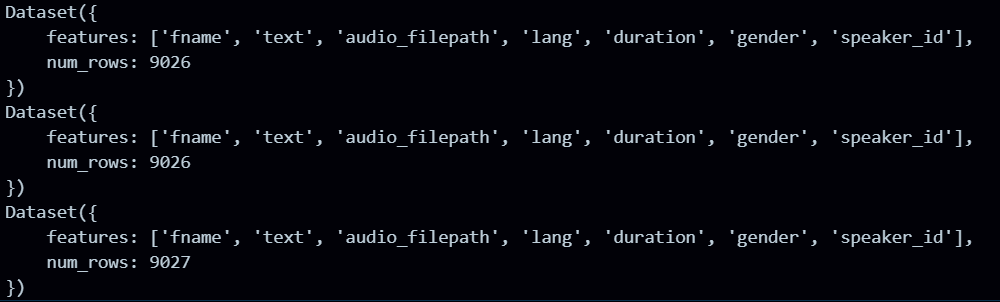

In [ ]:

def check_sample_rates(dataset, n_samples=500):
    rates = Counter()
    audio_col = next(c for c in dataset.column_names if dataset.features[c].__class__.__name__ == "Audio")
    for ex in dataset.select(range(min(n_samples, len(dataset)))):
        sr = ex[audio_col]["sampling_rate"]
        rates[sr] += 1
    return rates


print("Sample rates in train set:")
sr_counts = check_sample_rates(raw["train"], n_samples=500)

for sr, cnt in sorted(sr_counts.items()):
    print(f"  {sr} Hz  → {cnt} samples")

Sample rates in train set:

  16000 Hz  → 500 samples

In [ ]:
def build_vocab(dataset, text_col="sentence", n_samples=None):
    """Build word + character frequency from transcriptions."""
    word_counter = Counter()
    char_counter = Counter()
    subset = dataset if n_samples is None else dataset.select(range(min(n_samples, len(dataset))))
    for ex in subset:
        text = ex.get(text_col, ex.get("text", "")).strip()
        words = text.split()
        word_counter.update(words)
        char_counter.update(list(text.replace(" ", "")))
    return word_counter, char_counter

text_col = "sentence" if "sentence" in raw["train"].column_names else "text"

word_freq, char_freq = build_vocab(raw["train"], text_col=text_col, n_samples=5000)

print(f"Unique words : {len(word_freq):,}")
print(f"Unique chars : {len(char_freq):,}")
print("\nTop-30 words:")
for w, c in word_freq.most_common(30):
    print(f"  {w!r:30s} {c}")
print("\nTop-30 chars:")
for ch, c in char_freq.most_common(30):
    print(f"  {ch!r:10s} {c}")


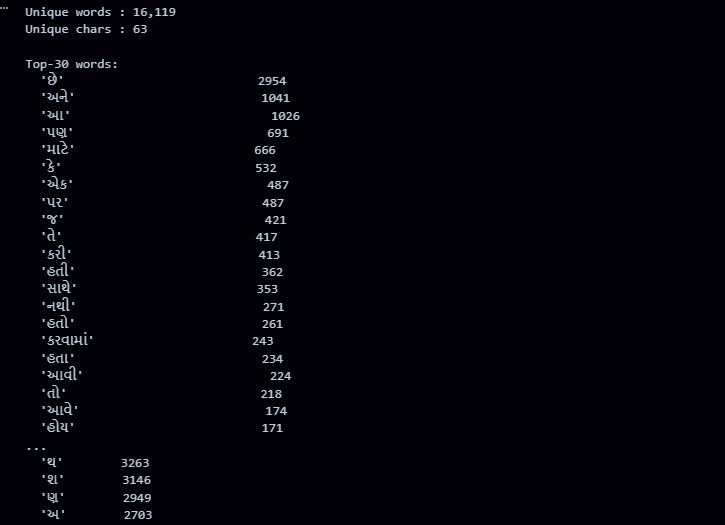

In [ ]:
vocab_path = Path(hp.output_dir)
vocab_path.mkdir(parents=True, exist_ok=True)
with open(vocab_path / "kathbath_gu_word_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(word_freq.most_common()), f, ensure_ascii=False, indent=2)
with open(vocab_path / "kathbath_gu_char_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(char_freq.most_common()), f, ensure_ascii=False, indent=2)



In [ ]:
def plot_frequency(counter, title, top_n=40, fname=None):
    labels, counts = zip(*counter.most_common(top_n))
    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(labels)), counts, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(labels))))
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=75, fontsize=8, ha="right")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150)
        wandb.log({title: wandb.Image(fname)})
    plt.show()

In [ ]:
plot_frequency(char_freq, "Gujarati Character Frequency (Kathbath)", top_n=50,
               fname=str(vocab_path / "char_freq.png"))
plot_frequency(word_freq, "Gujarati Word Frequency (Kathbath)", top_n=40,
               fname=str(vocab_path / "word_freq.png"))

In [ ]:
raw = raw.cast_column("audio", Audio(sampling_rate=hp.target_sr))

In [ ]:
def normalize_text(text: str) -> str:
    text = text.strip()
    import re
    text = re.sub(r"\s+", " ", text)
    return text

In [ ]:
from datasets import DatasetDict

AUDIO_COL = "audio_filepath"
TEXT_COL  = "text"

def prepare_dataset(batch):
    audio_data = batch[AUDIO_COL]


    if audio_data is None or audio_data["array"] is None:
        return {"input_features": None, "labels": None}

    waveform = np.array(audio_data["array"], dtype=np.float32)
    sr = audio_data["sampling_rate"]

    if len(waveform) == 0:
        return {"input_features": None, "labels": None}


    if len(waveform) > hp.max_input_length:
        waveform = waveform[:hp.max_input_length]

    min_len = int(0.5 * hp.target_sr)
    if len(waveform) < min_len:
        waveform = np.pad(waveform, (0, min_len - len(waveform)))

    
    input_features = feature_extractor(
        waveform,
        sampling_rate=hp.target_sr,
        return_tensors="np",
        padding="max_length",
        truncation=True,
    ).input_features[0]

    
    text = normalize_text(batch[TEXT_COL])
    labels = tokenizer(text).input_ids
    labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

    return {"input_features": input_features, "labels": labels}


processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=1,
        batched=False,  
        desc=f"Processing {split_name}"
    )
    
    mapped = mapped.filter(lambda x: x["input_features"] is not None)
    processed[split_name] = mapped


for split_name, split_data in processed.items():
    print(f"{split_name} size: {len(split_data)}")

train size: 9026 

validation size: 9026

test size: 9027

In [ ]:
print(train_ds[5])

{'fname': '844424930970288-107-f.m4a', 'text': 'તાજેતરમાં જ આ બન્ને માલદીવના વેકેશન પર પણ ગયા હતાં', 'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7cba03e3ea20>, 'lang': 'gu', 'duration': 4.66725, 'gender': 'Female', 'speaker_id': 107}

In [ ]:
print(processed)
print("input_features shape:", np.array(processed["train"][0]["input_features"]).shape)

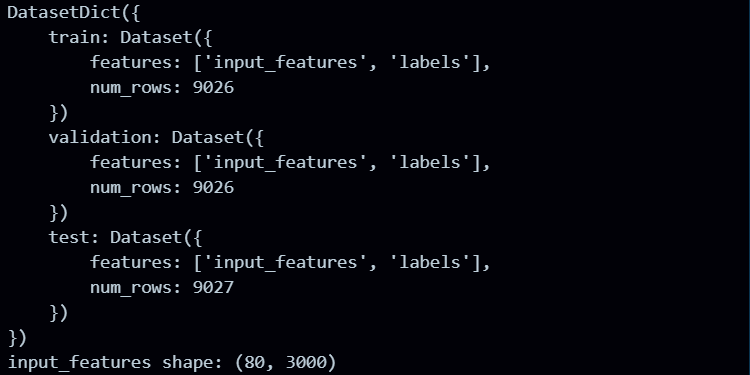 

In [ ]:
def tokenizer_sanity_check(n=5):
    print("=" * 60)
    print("TOKENIZER SANITY CHECK — Gujarati")
    print("=" * 60)
    indices = random.sample(range(len(raw["train"])), n)
    for i, idx in enumerate(indices):
        orig_text = normalize_text(raw["train"][idx].get(text_col, ""))
        token_ids = tokenizer(orig_text).input_ids
        decoded   = tokenizer.decode(token_ids, skip_special_tokens=True)
        print(f"\n[{i+1}] Original : {orig_text}")
        print(f"     Token IDs: {token_ids[:20]}{'…' if len(token_ids)>20 else ''}")
        print(f"     Decoded  : {decoded}")
        match = " MATCH" if orig_text.strip() == decoded.strip() else "  MISMATCH"
        print(f"     Status   : {match}")


tokenizer_sanity_check(5)

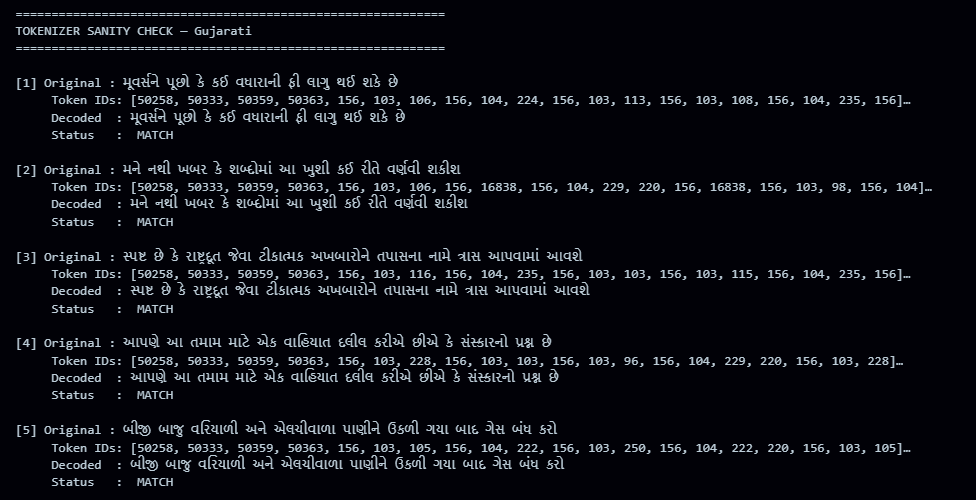

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Pad input features
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )
        
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


In [ ]:
base_model = WhisperForConditionalGeneration.from_pretrained(
    hp.model_name,
    torch_dtype=torch.float16 if hp.fp16 else torch.float32,
)
base_model.config.forced_decoder_ids = None
base_model.config.suppress_tokens    = []
base_model.config.use_cache          = False   

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training

In [ ]:
lora_config = LoraConfig(
    r=hp.lora_r,
    lora_alpha=hp.lora_alpha,
    target_modules=hp.lora_target_modules,
    lora_dropout=hp.lora_dropout,
    bias=hp.bias,
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


model.gradient_checkpointing_enable()

In [ ]:
for name, param in model.named_parameters():
    if "encoder" in name and "lora" not in name:
        param.requires_grad = False


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable params: 12,976,128 / 254,711,040 (5.09%)

In [ ]:
# def save_and_download_dataset(dataset, save_path="/content/processed_ds"):
#     import os
#     import shutil
#     from google.colab import files

#     # Step 1: Remove unused columns (important for size)
#     keep_cols = ["input_features", "labels"]
#     dataset = dataset.remove_columns(
#         [col for col in dataset.column_names if col not in keep_cols]
#     )

#     print("Saving dataset to disk...")
#     dataset.save_to_disk(save_path)

#     # Step 2: Zip the folder
#     zip_path = save_path + ".zip"
#     print("Zipping dataset...")
#     shutil.make_archive(save_path, 'zip', save_path)

#     # Step 3: Show size
#     size = os.path.getsize(zip_path) / (1024**3)
#     print(f"Zip size: {size:.2f} GB")

#     # Step 4: Download
#     print("Downloading...")
#     files.download(zip_path)

#     print("Done ✅")

In [ ]:
def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_str  = [normalize_text(t) for t in pred_str]
    label_str = [normalize_text(t) for t in label_str]

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)


    return {
        "wer":    round(wer,    4),
        "cer":    round(cer,    4),}


In [ ]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=hp.output_dir,


    per_device_train_batch_size=hp.per_device_train_bs,
    per_device_eval_batch_size=hp.per_device_eval_bs,
    gradient_accumulation_steps=hp.gradient_accumulation,
    gradient_checkpointing=True,

    learning_rate=hp.learning_rate,
    warmup_steps=hp.warmup_steps,
    weight_decay=hp.weight_decay,
    max_grad_norm=hp.max_grad_norm,
    num_train_epochs=hp.num_train_epochs,
    lr_scheduler_type="cosine",

    fp16=hp.fp16,


    eval_strategy=hp.eval_strategy,
    save_strategy=hp.save_strategy,
    logging_steps=hp.logging_steps,
    load_best_model_at_end=hp.load_best_model,
    metric_for_best_model=hp.metric_for_best,
    greater_is_better=hp.greater_is_better,
    save_total_limit=3,

    predict_with_generate=hp.predict_with_generate,
    generation_max_length=hp.generation_max_length,

    
    report_to="wandb",
    run_name=hp.wandb_run_name,

    
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    push_to_hub=False,
    label_names=["labels"],
)


In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=processed["train"],
    eval_dataset=processed["validation"],
     processing_class=processor.feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=hp.early_stopping_patience)],
)

In [ ]:
processed = processed.filter(
    lambda x: x["input_features"] is not None and x["labels"] is not None
)

In [ ]:
from datasets import DatasetDict

processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=1,  
        desc=f"Processing {split_name}"
    )
    
    mapped = mapped.filter(lambda x: x["input_features"] is not None)
    processed[split_name] = mapped

for split_name, split_data in processed.items():
    print(f"{split_name} size: {len(split_data)}")

In [ ]:
for i in range(5):
    print(processed["train"][i])

In [ ]:
print("Starting training…")
train_result = trainer.train()

trainer.save_model(hp.output_dir)
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()
print("Training complete. Adapter saved to:", hp.output_dir)

In [ ]:
def plot_training_curves(log_history: List[Dict], save_dir: str = "."):
    """Parse trainer log_history and plot loss + WER/CER curves."""
    train_steps, train_loss = [], []
    eval_steps, eval_loss   = [], []
    eval_wer, eval_cer      = [], []

    for entry in log_history:
        step = entry.get("step", 0)
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(step)
            train_loss.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])
        if "eval_wer" in entry:
            eval_wer.append(entry["eval_wer"])
        if "eval_cer" in entry:
            eval_cer.append(entry["eval_cer"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    
    axes[0].plot(train_steps, train_loss, label="Train Loss", color="#1f77b4", lw=1.5)
    axes[0].plot(eval_steps,  eval_loss,  label="Val Loss",   color="#ff7f0e", lw=1.5, marker="o", ms=4)
    axes[0].set_title("Loss Curve", fontweight="bold")
    axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)


    axes[1].plot(eval_steps[:len(eval_wer)], eval_wer, color="#2ca02c", lw=1.5, marker="s", ms=4)
    axes[1].set_title("Validation WER", fontweight="bold")
    axes[1].set_xlabel("Steps"); axes[1].set_ylabel("WER (lower = better)")
    axes[1].grid(alpha=0.3)


    axes[2].plot(eval_steps[:len(eval_cer)], eval_cer, color="#d62728", lw=1.5, marker="^", ms=4)
    axes[2].set_title("Validation CER", fontweight="bold")
    axes[2].set_xlabel("Steps"); axes[2].set_ylabel("CER (lower = better)")
    axes[2].grid(alpha=0.3)

    plt.suptitle("Whisper-Small LoRA | Kathbath Gujarati", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "training_curves.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"training_curves": wandb.Image(fpath)})
    plt.show()


In [ ]:
def plot_spectrograms(dataset_raw, n=5, text_col="sentence", save_dir="."):
    indices = random.sample(range(len(dataset_raw)), n)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ex = dataset_raw[idx]
        waveform = np.array(ex["audio"]["array"], dtype=np.float32)
        sr = ex["audio"]["sampling_rate"]
        text = ex.get(text_col, ex.get("text", ""))

        S = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=80, fmax=8000)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                                        fmax=8000, ax=ax, cmap="magma")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")
        ax.set_title(f"[{idx}] {text[:80]}…" if len(text) > 80 else f"[{idx}] {text}",
                     fontsize=9)
    plt.suptitle("Mel Spectrograms — Kathbath Gujarati", fontsize=12, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "spectrograms.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"spectrograms": wandb.Image(fpath)})
    plt.show()

In [ ]:
plot_training_curves(trainer.state.log_history, save_dir=hp.output_dir)

In [ ]:
plot_spectrograms(raw["train"], n=5, text_col=text_col, save_dir=hp.output_dir)

In [ ]:
print("---------------Test Eval--------------")
test_results = trainer.evaluate(
    eval_dataset=processed["test"],
    metric_key_prefix="test",
)
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
print(test_results)
wandb.log(test_results)

In [ ]:
!pip install optimum[onnxruntime]

In [ ]:
def run_full_inference(model, processor, dataset_raw, dataset_proc, n_samples=None, text_col="sentence"):
    """Run inference on test set and compute detailed metrics."""
    model.eval()
    all_preds, all_refs = [], []

    n = n_samples or len(dataset_proc)
    indices = list(range(min(n, len(dataset_proc))))

    print(f"Running inference on {len(indices)} test samples…")
    batch_size = 8
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch_features = torch.tensor(
            np.stack([dataset_proc[i]["input_features"] for i in batch_idx]),
            dtype=torch.float16 if hp.fp16 else torch.float32,
        ).to(DEVICE)

        with torch.no_grad():
            pred_ids = model.generate(
                batch_features,
                forced_decoder_ids=processor.get_decoder_prompt_ids(
                    language=hp.language, task=hp.task
                ),
                max_new_tokens=hp.generation_max_length,
            )

        preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
        refs  = [
            normalize_text(dataset_raw[i].get(text_col, ""))
            for i in batch_idx
        ]
        all_preds.extend([normalize_text(p) for p in preds])
        all_refs.extend(refs)

    wer_score = wer_metric.compute(predictions=all_preds, references=all_refs)
    cer_score = cer_metric.compute(predictions=all_preds, references=all_refs)



    results = {
        "test_wer":    round(wer_score, 4),
        "test_cer":    round(cer_score, 4),
    }
    print("\n── Final Test Metrics ──────────────────────────────")
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")

    wandb.log(results)

    print("\n── Sample Predictions ──────────────────────────────")
    for i in range(min(10, len(all_preds))):
        print(f"[{i+1}] REF : {all_refs[i]}")
        print(f"     PRED: {all_preds[i]}")
        print()

    return all_preds, all_refs, results

In [ ]:
best_model = WhisperForConditionalGeneration.from_pretrained(hp.model_name)
best_model.config.forced_decoder_ids = None
best_model.config.suppress_tokens    = []
best_model = PeftModel.from_pretrained(best_model, hp.output_dir)
best_model = best_model.merge_and_unload()   
best_model = best_model.to(DEVICE)
if hp.fp16:
    best_model = best_model.half()

preds, refs, final_metrics = run_full_inference(
    best_model, processor,
    raw["test"], processed["test"],
    text_col=text_col,
)

In [ ]:
BEST_MODEL_DIR = Path(hp.output_dir) / "best_merged"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(str(BEST_MODEL_DIR))
processor.save_pretrained(str(BEST_MODEL_DIR))
tokenizer.save_pretrained(str(BEST_MODEL_DIR))
print("Merged model saved to:", BEST_MODEL_DIR)

In [ ]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "hyperparams": hp.__dict__,
        "final_metrics": final_metrics,
    },
    str(BEST_MODEL_DIR / "checkpoint.pt"),
)
print("PyTorch checkpoint saved.")

In [ ]:
from optimum.onnxruntime import ORTModelForSpeechSeq2Seq
from transformers import pipeline as hf_pipeline

print("\nExporting to ONNX (optimum)…")
ONNX_DIR = Path(hp.onnx_dir)
ONNX_DIR.mkdir(parents=True, exist_ok=True)

ort_model = ORTModelForSpeechSeq2Seq.from_pretrained(
    str(BEST_MODEL_DIR),
    export=True,
    provider="CPUExecutionProvider",
)
ort_model.save_pretrained(str(ONNX_DIR))
processor.save_pretrained(str(ONNX_DIR))
print(f"ONNX model saved to: {ONNX_DIR}")

In [ ]:
onnx_pipe = hf_pipeline(
    "automatic-speech-recognition",
    model=ort_model,
    tokenizer=tokenizer,
    feature_extractor=feature_extractor,
)
sample_audio = raw["test"][0]["audio"]
onnx_out = onnx_pipe({"sampling_rate": sample_audio["sampling_rate"],
                        "raw": sample_audio["array"]})
print("ONNX test output:", onnx_out["text"])
print("Reference        :", normalize_text(raw["test"][0].get(text_col, "")))

In [ ]:
import zipfile
import shutil
from google.colab import files as colab_files

In [ ]:
def zip_and_download(source_dir: str, zip_name: str):
    """Zip a directory and trigger a browser download in Colab."""
    zip_path = f"/content/{zip_name}"
    print(f"Zipping {source_dir} → {zip_path} …")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for fpath in Path(source_dir).rglob("*"):
            if fpath.is_file():
                zf.write(fpath, arcname=fpath.relative_to(source_dir))
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f"Archive size: {size_mb:.1f} MB")
    colab_files.download(zip_path)
    print(f"Download triggered for: {zip_name}")

In [ ]:
zip_and_download(hp.output_dir, "whisper_small_gu_lora_adapter.zip")
zip_and_download(hp.onnx_dir, "whisper_small_gu_onnx.zip")
colab_files.download(str(BEST_MODEL_DIR / "checkpoint.pt"))

In [ ]:
artifact = wandb.Artifact("whisper-small-gu-lora", type="model")
artifact.add_dir(hp.output_dir)
run.log_artifact(artifact)
wandb.finish()
print("W&B run finished. All artifacts logged.")